# End-to-End Hierarchical IDS System Execution

This notebook executes the final hierarchical IDS end-to-end on a held-out test set.
All models, thresholds, and safety parameters are fixed based on prior validation analysis.
The test split is recreated deterministically using the same procedure as Notebook 1.
No training, tuning, or threshold optimisation is performed here.


In [10]:
# -------------------------------
# 0. LOOKUP Dictionary
# -------------------------------
SCENARIO_LOOKUP = {
    # Natural Faults (1–6)
    1: "Fault L1 (10–19%)",
    2: "Fault L1 (20–79%)",
    3: "Fault L1 (80–90%)",
    4: "Fault L2 (10–19%)",
    5: "Fault L2 (20–79%)",
    6: "Fault L2 (80–90%)",

    # Maintenance (13–14)
    13: "Line Maintenance L1",
    14: "Line Maintenance L2",

    # Data Injection Attacks (7–12)
    7:  "Data Injection: L1 Fault 10–19% with tripping",
    8:  "Data Injection: L1 Fault 20–79% with tripping",
    9:  "Data Injection: L1 Fault 80–90% with tripping",
    10: "Data Injection: L2 Fault 10–19% with tripping",
    11: "Data Injection: L2 Fault 20–79% with tripping",
    12: "Data Injection: L2 Fault 80–90% with tripping",

    # Remote Tripping Attacks (15–20)
    15: "Remote Tripping: Command Injection R1",
    16: "Remote Tripping: Command Injection R2",
    17: "Remote Tripping: Command Injection R3",
    18: "Remote Tripping: Command Injection R4",
    19: "Remote Tripping: Command Injection R1 & R2",
    20: "Remote Tripping: Command Injection R3 & R4",

    # Relay Setting Change (21–30)
    21: "Relay Setting Change: R1 disabled (L1 10–19% fault)",
    22: "Relay Setting Change: R1 disabled (L1 20–90% fault)",
    23: "Relay Setting Change: R2 disabled (L1 10–49% fault)",
    24: "Relay Setting Change: R2 disabled (L1 50–79% fault)",
    25: "Relay Setting Change: R2 disabled (L1 80–90% fault)",
    26: "Relay Setting Change: R3 disabled (L2 10–19% fault)",
    27: "Relay Setting Change: R3 disabled (L2 20–49% fault)",
    28: "Relay Setting Change: R3 disabled (L2 50–90% fault)",
    29: "Relay Setting Change: R4 disabled (L2 10–79% fault)",
    30: "Relay Setting Change: R4 disabled (L2 80–90% fault)",

    # Relay Setting Change (two relays + fault)
    35: "Relay Setting Change: R1 & R2 disabled (L1 10–49% fault)",
    36: "Relay Setting Change: R1 & R2 disabled (L1 50–90% fault)",
    37: "Relay Setting Change: R3 & R4 disabled (L1 10–49% fault)",
    38: "Relay Setting Change: R3 & R4 disabled (L1 50–90% fault)",

    # Relay Setting Change (two relays + maintenance)
    39: "Relay Setting Change: R1 & R2 disabled during maintenance",
    40: "Relay Setting Change: R1 & R2 disabled during maintenance",

    # Normal Operation
    41: "Normal Operation (no disturbances)"
}

DI_NAMES = {
    7: "DI: Fault 10–19% L1",
    8: "DI: Fault 20–79% L1",
    9: "DI: Fault 80–90% L1",
    10: "DI: Fault 10–19% L2",
    11: "DI: Fault 20–79% L2",
    12: "DI: Fault 80–90% L2"
}

RT_NAMES = {
    15: "Remote Trip: Cmd R1",
    16: "Remote Trip: Cmd R2",
    17: "Remote Trip: Cmd R3",
    18: "Remote Trip: Cmd R4",
    19: "Remote Trip: Cmd R1 & R2",
    20: "Remote Trip: Cmd R3 & R4"
}

RSC_NAMES = {
    21: "RSC: L1 R1 Disabled (10–19%)",
    22: "RSC: L1 R1 Disabled (20–90%)",
    23: "RSC: L1 R2 Disabled (10–49%)", 
    24: "RSC: L1 R2 Disabled (50–79%)",
    25: "RSC: L1 R2 Disabled (80–90%)",
    26: "RSC: L2 R3 Disabled (10–19%)",
    27: "RSC: L2 R3 Disabled (20–49%)",
    28: "RSC: L2 R3 Disabled (50–90%)",
    29: "RSC: L2 R4 Disabled (10–79%)",
    30: "RSC: L2 R4 Disabled (80–90%)",
    35: "RSC: L1 R1&R2 Disabled (10–49%)",
    36: "RSC: L1 R1&R2 Disabled (50–90%)",
    37: "RSC: L1 R3&R4 Disabled (10–49%)",
    38: "RSC: L1 R3&R4 Disabled (50–90%)",
    39: "RSC: L1 Maint R1&R2 Disabled",
    40: "RSC: L1 Maint R1&R2 Disabled"
}


In [11]:
import numpy as np
import pandas as pd
import joblib
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)


In [12]:
# ------------------------------------------------------------
# Load full dataset (same source as Notebook 1)
# ------------------------------------------------------------
DATA_PATH = "../data/merged/multi_class_dataset_clean_FULL.csv"

df = pd.read_csv(DATA_PATH)

FEATURE_COLS = [
    c for c in df.columns
    if c not in ["marker", "label", "label_name"]
]

X_all = df[FEATURE_COLS]
y_marker = df["marker"]

# ------------------------------------------------------------
# Binary labels for M1 (same mapping as Notebook 1)
# ------------------------------------------------------------
NON_ATTACK_IDS = [1,2,3,4,5,6,13,14,41]

def map_M1(marker):
    return 1 if marker in NON_ATTACK_IDS else 0  # 1=Non-attack, 0=Attack

y_M1 = y_marker.apply(map_M1)

# ------------------------------------------------------------
# Recreate test split deterministically
# ------------------------------------------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all,
    y_M1,
    test_size=0.20,
    random_state=42,
    stratify=y_M1
)

is_attack_test = (y_test == 0)

print("Test samples:", len(X_test))
print("Attack fraction:", is_attack_test.mean())


Test samples: 15676
Attack fraction: 0.7101939270221995


In [13]:
# ------------------------------------------------------------
# Load all frozen models
# ------------------------------------------------------------
M1 = joblib.load("../models/M1.joblib")
M2 = joblib.load("../models/M2.joblib")
M3 = joblib.load("../models/M3.joblib")
M4 = joblib.load("../models/M4.joblib")
M5 = joblib.load("../models/M5.joblib")
M6 = joblib.load("../models/M6.joblib")

ATTACK_LABEL_IDX = 0  # attack index in M1.predict_proba

print("Models M1–M6 loaded.")


Models M1–M6 loaded.


In [14]:

# ============================================================
# Feature Name Mapping (Human Readable)
# ============================================================

def readable_feature(name):

    relay = name.split("-")[0]

    # ---------------- Voltage Magnitude ----------------
    if "PM1:V" in name:
        return f"{relay} Phase A Voltage Magnitude"

    if "PM2:V" in name:
        return f"{relay} Phase B Voltage Magnitude"

    if "PM3:V" in name:
        return f"{relay} Phase C Voltage Magnitude"

    # ---------------- Current Magnitude ----------------
    if "PM4:I" in name:
        return f"{relay} Phase A Current Magnitude"

    if "PM5:I" in name:
        return f"{relay} Phase B Current Magnitude"

    if "PM6:I" in name:
        return f"{relay} Phase C Current Magnitude"

    # ---------------- Voltage Angle ----------------
    if "PA1:VH" in name:
        return f"{relay} Phase A Voltage Angle"

    if "PA2:VH" in name:
        return f"{relay} Phase B Voltage Angle"

    if "PA3:VH" in name:
        return f"{relay} Phase C Voltage Angle"

    # ---------------- Current Angle ----------------
    if "PA4:IH" in name:
        return f"{relay} Phase A Current Angle"

    if "PA5:IH" in name:
        return f"{relay} Phase B Current Angle"

    if "PA6:IH" in name:
        return f"{relay} Phase C Current Angle"

    # ---------------- Sequence Components ----------------
    if "PM7:V" in name:
        return f"{relay} Positive Sequence Voltage"

    if "PM8:V" in name:
        return f"{relay} Negative Sequence Voltage"

    if "PM9:V" in name:
        return f"{relay} Zero Sequence Voltage"

    if "PM10:I" in name:
        return f"{relay} Positive Sequence Current"

    if "PM11:I" in name:
        return f"{relay} Negative Sequence Current"

    if "PM12:I" in name:
        return f"{relay} Zero Sequence Current"

    # ---------------- Frequency ----------------
    if ":F" in name:
        return f"{relay} Frequency"

    if ":DF" in name:
        return f"{relay} Frequency Change Rate"

    # ---------------- Impedance ----------------
    if ":Z" in name:
        return f"{relay} Apparent Impedance"

    if ":ZH" in name:
        return f"{relay} Impedance Angle"

    # ---------------- Status ----------------
    if ":S" in name:
        return f"{relay} Relay Status"

    return name

M1 Attack Detector → No feature importance available


M2 Non-Attack
R4 Phase B Voltage Magnitude : 0.0485
R4 Positive Sequence Voltage : 0.0307
R2 Apparent Impedance : 0.0261
R3 Apparent Impedance : 0.0256
R1 Phase B Voltage Magnitude : 0.0225
R4 Apparent Impedance : 0.0204
R4 Phase A Voltage Magnitude : 0.0204
R4 Phase C Voltage Magnitude : 0.0196
R2 Phase C Voltage Magnitude : 0.0187
R3 Zero Sequence Current : 0.0164


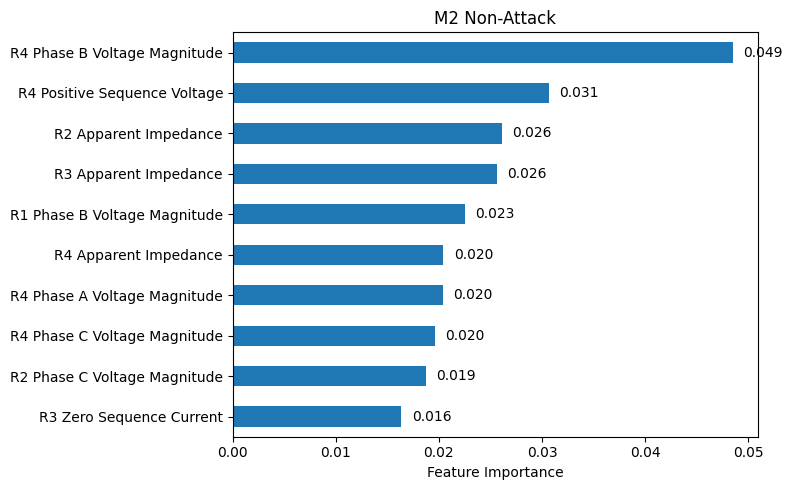


M3 Attack Family
R3 Phase B Voltage Magnitude : 0.0221
R1 Phase B Voltage Magnitude : 0.0211
R4 Phase B Voltage Magnitude : 0.0183
R1 Phase B Current Magnitude : 0.0152
R2 Phase B Current Magnitude : 0.0151
R4 Phase B Current Magnitude : 0.0150
R3 Phase B Current Magnitude : 0.0149
R2 Phase B Current Angle : 0.0148
R3 Phase B Current Angle : 0.0147
R1 Phase B Voltage Angle : 0.0146


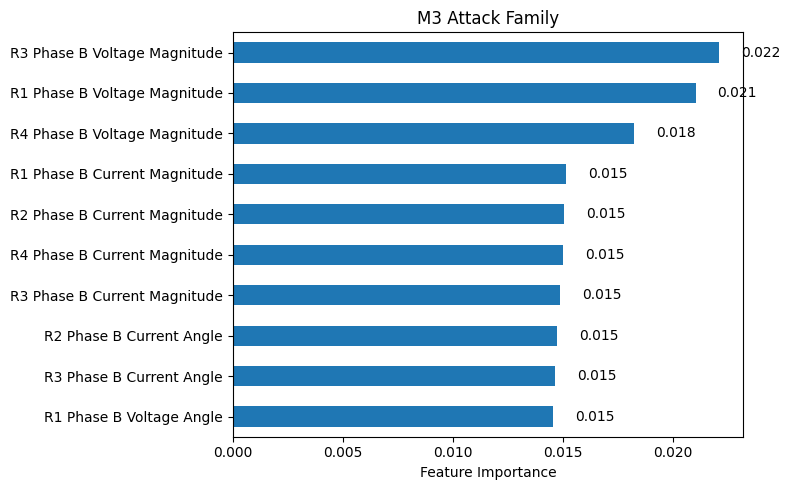


M4 Data Injection
R4 Phase B Voltage Magnitude : 0.0359
R1 Phase B Voltage Magnitude : 0.0214
R4 Positive Sequence Voltage : 0.0212
R2 Phase C Voltage Magnitude : 0.0208
R2 Phase A Voltage Magnitude : 0.0175
R4 Phase B Voltage Angle : 0.0169
R1 Phase B Voltage Angle : 0.0168
R2 Positive Sequence Voltage : 0.0159
R1 Phase B Current Magnitude : 0.0158
R4 Phase C Voltage Magnitude : 0.0155


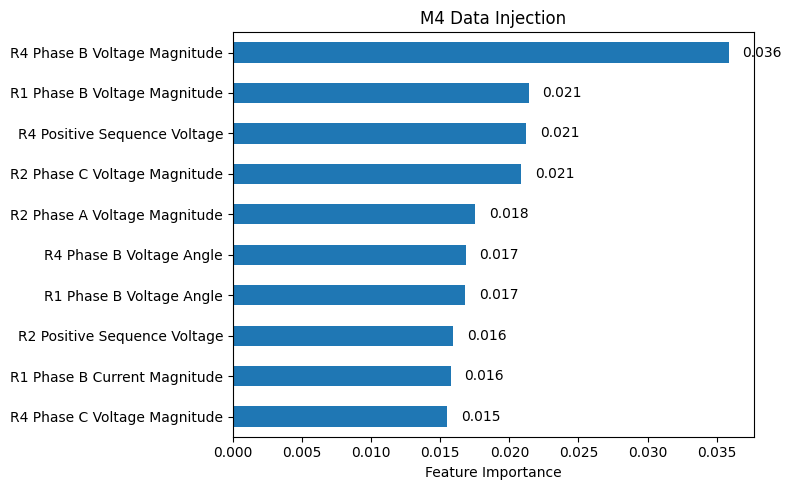


M5 Remote Tripping
R4 Phase B Voltage Magnitude : 0.0382
R2 Phase C Voltage Magnitude : 0.0209
R4 Positive Sequence Voltage : 0.0196
R1 Phase B Voltage Magnitude : 0.0186
R2 Positive Sequence Voltage : 0.0183
R2 Phase A Voltage Magnitude : 0.0181
R1 Phase B Current Magnitude : 0.0175
R4 Phase B Current Magnitude : 0.0171
R2 Phase B Current Magnitude : 0.0169
R3 Phase B Current Magnitude : 0.0167


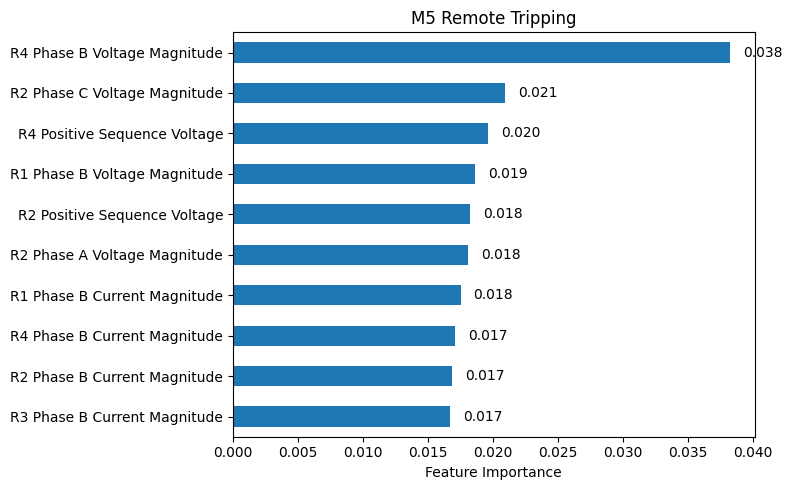


M6 Relay Setting Change
R1 Phase B Voltage Magnitude : 0.0312
R3 Phase B Voltage Magnitude : 0.0273
R4 Phase B Voltage Magnitude : 0.0226
R4 Phase B Current Magnitude : 0.0176
R1 Phase B Current Magnitude : 0.0172
R2 Phase B Current Magnitude : 0.0168
R3 Phase B Current Magnitude : 0.0168
R4 Positive Sequence Voltage : 0.0154
R4 Phase C Voltage Angle : 0.0154
R1 Phase C Voltage Angle : 0.0153


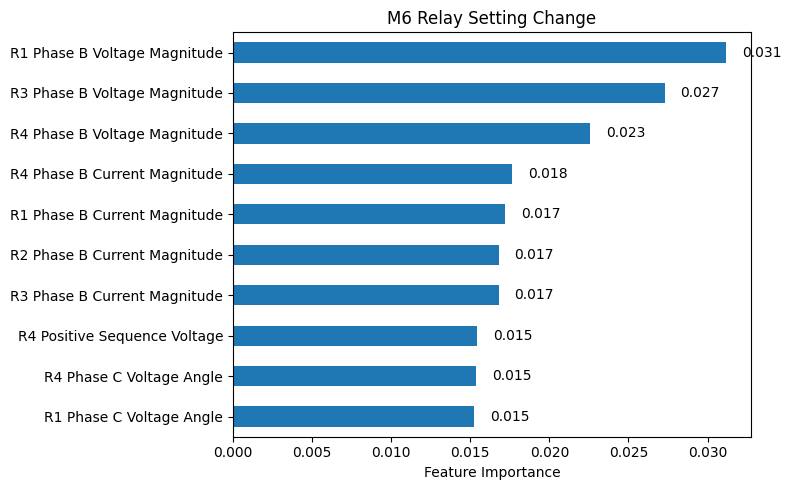

In [15]:
# ============================================================
# Feature Importance (List + Plot)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

models = {
    "M1 Attack Detector": M1,
    "M2 Non-Attack": M2,
    "M3 Attack Family": M3,
    "M4 Data Injection": M4,
    "M5 Remote Tripping": M5,
    "M6 Relay Setting Change": M6
}

top_k = 10

for name, model in models.items():

    if not hasattr(model, "feature_importances_"):
        print(f"{name} → No feature importance available\n")
        continue

    importance = pd.Series(
        model.feature_importances_,
        index=FEATURE_COLS
    )

    top_features = importance.sort_values(ascending=False).head(top_k)

    # Convert to readable names
    readable = [readable_feature(f) for f in top_features.index]

    print("\n===============================")
    print(name)
    print("===============================")

    for f, v in zip(readable, top_features.values):
        print(f"{f} : {v:.4f}")

    # ---------- Plot ----------
    top_features.index = readable

    plt.figure(figsize=(8,5))

    ax = top_features.sort_values().plot(
        kind="barh"
    )

    plt.title(name)
    plt.xlabel("Feature Importance")

    # attach values
    for i, v in enumerate(top_features.sort_values()):
        ax.text(v + 0.001, i, f"{v:.3f}", va="center")

    plt.tight_layout()
    plt.show()

In [16]:
# ------------------------------------------------------------
# Fixed parameters from validation analysis
# ------------------------------------------------------------
TAU_GATE = 0.2984
CONF_FALLBACK = 0.8133
SAFE_MARGIN = 0.1040


In [17]:
# ------------------------------------------------------------
# M2 label map (local index → non-attack family)
# ------------------------------------------------------------
# Used only for end-to-end inference output

M2_LABELS = {
0: "SLG Faults",
1: "Line Maintenance",
2: "Normal Operation"
}

# ------------------------------------------------------------
# Inverse maps: leaf index → real scenario ID (ATTACKS ONLY)
# ------------------------------------------------------------
# ------------------------------------------------------------
# Attack scenario IDs
# ------------------------------------------------------------

# Data Injection
DI_IDS = [7, 8, 9, 10, 11, 12]

# Remote Tripping
RT_IDS = [15, 16, 17, 18, 19, 20]

# Relay Setting Change
RSC_IDS = [
    21,22,23,24,25,26,27,28,29,30,
    35,36,37,38,39,40
]

M4_INV_MAP = {i: k for i, k in enumerate(DI_IDS)}
M5_INV_MAP = {i: k for i, k in enumerate(RT_IDS)}
M6_INV_MAP = {i: k for i, k in enumerate(RSC_IDS)}

In [18]:
# ============================================================
# Get Top Contributing Features
# ============================================================

def get_top_features(model, feature_names, k=3):

    if not hasattr(model, "feature_importances_"):
        return None

    importances = model.feature_importances_

    pairs = list(zip(feature_names, importances))

    pairs.sort(key=lambda x: x[1], reverse=True)

    top = pairs[:k]

    factors = [
        (readable_feature(feature), f"{importance*100:.1f}%")
        for feature, importance in top
    ]

    return factors

In [19]:
# ============================================================
# Hierarchical Prediction Function
# ============================================================
def hierarchical_predict(X, y_true_marker=None):

    records = []

    # M1 attack probability (routing gate)
    m1_probs = M1.predict_proba(X)[:, ATTACK_LABEL_IDX]

    for i in tqdm(range(len(X)), desc="End-to-End IDS Inference", unit="sample"):
        sample = X.iloc[[i]]
        p_attack = float(m1_probs[i])

        record = {
            # --- routing confidence ---
            "M1_conf": p_attack,
            "M3_conf": None,
            "Leaf_conf": None,

            # --- system output ---
            "Final_binary": None,     # 0 = Non-Attack, 1 = Attack
            "Final_class": None,      # scenario ID (ATTACKS ONLY)
            "Final_label": None,      # human-readable (family or attack)
            "Final_conf": None,
            "Decision": None,
            "Path": None,
            
            # --- explainability ---
            "Contributing_Factors": None
        }

        # --- optional ground truth (evaluation only) ---
        if y_true_marker is not None:
            true_marker = int(y_true_marker.iloc[i])
            record["True_marker"] = true_marker
            record["True_label_name"] = SCENARIO_LOOKUP.get(true_marker, "Unknown")

        # =====================================================
        # M1 ROUTING
        # =====================================================
        if p_attack < TAU_GATE:
            # ---------------- NON-ATTACK PATH (M2) ----------------
            m2_probs = M2.predict_proba(sample)[0]
            m2_pred = int(np.argmax(m2_probs))
            m2_conf = float(m2_probs[m2_pred])
            
        # ---------------- EXPLAINABILITY ----------------

            factors = get_top_features(
                M2,
                X.columns,
                k=3
            )

            record.update({
                "Final_binary": 0,
                "Final_label": M2_LABELS[m2_pred],
                "Final_conf": m2_conf,
                "Decision": "M2_DIRECT",
                "Path": "M1 → M2",
                "Contributing_Factors": factors
            })

        else:
            # ---------------- ATTACK PATH (M3) ----------------
            m3_probs = M3.predict_proba(sample)[0]
            m3_pred = int(np.argmax(m3_probs))
            m3_conf = float(m3_probs[m3_pred])

            record["M3_conf"] = m3_conf

            # -------- SAFE FALLBACK --------
            if (m3_conf < CONF_FALLBACK) and (p_attack < TAU_GATE + SAFE_MARGIN):
                m2_probs = M2.predict_proba(sample)[0]
                m2_pred = int(np.argmax(m2_probs))
                m2_conf = float(m2_probs[m2_pred])

            # ---------------- EXPLAINABILITY ----------------

                factors = get_top_features(
                    M2,
                    X.columns,
                    k=3
                )

                record.update({
                    "Final_binary": 0,
                    "Final_label": M2_LABELS[m2_pred],
                    "Final_conf": m2_conf,
                    "Decision": "FALLBACK_TO_M2",
                    "Path": "M1 → M3 → M2",
                    "Contributing_Factors": factors
                })
            
            else:

                # -------- SPECIALIST MODELS --------
                if m3_pred == 0:
                    leaf_model = M4
                    inv_map = M4_INV_MAP
                    path = "M1 → M3 → M4"

                elif m3_pred == 1:
                    leaf_model = M5
                    inv_map = M5_INV_MAP
                    path = "M1 → M3 → M5"

                else:
                    leaf_model = M6
                    inv_map = M6_INV_MAP
                    path = "M1 → M3 → M6"

                leaf_probs = leaf_model.predict_proba(sample)[0]
                leaf_pred = int(np.argmax(leaf_probs))
                leaf_conf = float(np.max(leaf_probs))

                final_class = inv_map[leaf_pred]
                # ---------------- EXPLAINABILITY ----------------

                factors = get_top_features(
                    leaf_model,
                    X.columns,
                    k=3
                )

                record.update({
                    "Final_binary": 1,
                    "Final_class": final_class,
                    "Final_label": SCENARIO_LOOKUP.get(final_class, "Unknown Scenario"),
                    "Final_conf": leaf_conf,
                    "Leaf_conf": leaf_conf,
                    "Decision": "ATTACK_CONFIRMED",
                    "Path": path,
                    "Contributing_Factors": factors
                })

        records.append(record)

    return pd.DataFrame(records)

In [20]:
# ============================================================
# Run End-to-End Inference (TEST SET)
# ============================================================
results_df = hierarchical_predict(
    X_test,
    y_marker.loc[X_test.index]
)

# ============================================================
# Clean Table Layout
# ============================================================
results_df = results_df[
    [
        # ----------------------------------------------------
        # Routing & Decision Path
        # ----------------------------------------------------
        "Decision",
        "Path",

        # ----------------------------------------------------
        # Model Confidence (hierarchical)
        # ----------------------------------------------------
        "M1_conf",
        "M3_conf",
        "Leaf_conf",

        # ----------------------------------------------------
        # Final System Prediction
        # ----------------------------------------------------
        "Final_binary",
        "Final_class",
        "Final_label",
        "Final_conf",

        # ----------------------------------------------------
        # Explainability
        # ----------------------------------------------------
        "Contributing_Factors",

        # ----------------------------------------------------
        # Ground Truth (evaluation only)
        # ----------------------------------------------------
        "True_marker",
        "True_label_name"
    ]
].reset_index(drop=True)
prob_cols = ["M1_conf", "M3_conf", "Leaf_conf", "Final_conf"]

# Keep numeric copy
results_df_numeric = results_df.copy()

# Step 1: round raw probabilities
results_df[prob_cols] = results_df[prob_cols].round(4)

# Step 2: convert to percentage
results_df[prob_cols] = results_df[prob_cols] * 100

# Step 3: round to 2 decimal places
results_df[prob_cols] = results_df[prob_cols].round(2)

# Step 4: add % sign
results_df[prob_cols] = results_df[prob_cols].applymap(
    lambda x: f"{x:.2f}%" if pd.notnull(x) else x
)

print("✅ End-to-end hierarchical inference complete")

results_df.head(30)

End-to-End IDS Inference:   0%|          | 0/15676 [00:00<?, ?sample/s]

✅ End-to-end hierarchical inference complete


/var/folders/nv/f9_p0fkx4xsf4ygmqb8ynm9w0000gn/T/ipykernel_17655/159531733.py:62: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  results_df[prob_cols] = results_df[prob_cols].applymap(


,Decision,Path,M1_conf,M3_conf,Leaf_conf,Final_binary,Final_class,Final_label,Final_conf,Contributing_Factors,True_marker,True_label_name
0,FALLBACK_TO_M2,M1 → M3 → M2,31.45%,39.00%,NaN,0,NaN,SLG Faults,61.67%,"[(R4 Phase B Voltage Magnitude, 4.9%), (R4 Pos...",13,Line Maintenance L1
1,ATTACK_CONFIRMED,M1 → M3 → M6,98.32%,84.33%,65.33%,1,23.0,Relay Setting Change: R2 disabled (L1 10–49% f...,65.33%,"[(R1 Phase B Voltage Magnitude, 3.1%), (R3 Pha...",23,Relay Setting Change: R2 disabled (L1 10–49% f...
2,ATTACK_CONFIRMED,M1 → M3 → M6,42.92%,44.00%,70.00%,1,36.0,Relay Setting Change: R1 & R2 disabled (L1 50–...,70.00%,"[(R1 Phase B Voltage Magnitude, 3.1%), (R3 Pha...",4,Fault L2 (10–19%)
3,ATTACK_CONFIRMED,M1 → M3 → M4,42.63%,100.00%,99.33%,1,12.0,Data Injection: L2 Fault 80–90% with tripping,99.33%,"[(R4 Phase B Voltage Magnitude, 3.6%), (R1 Pha...",12,Data Injection: L2 Fault 80–90% with tripping
4,FALLBACK_TO_M2,M1 → M3 → M2,32.01%,60.67%,NaN,0,NaN,Normal Operation,50.33%,"[(R4 Phase B Voltage Magnitude, 4.9%), (R4 Pos...",19,Remote Tripping: Command Injection R1 & R2
5,FALLBACK_TO_M2,M1 → M3 → M2,40.15%,50.33%,NaN,0,NaN,Normal Operation,89.67%,"[(R4 Phase B Voltage Magnitude, 4.9%), (R4 Pos...",41,Normal Operation (no disturbances)
6,ATTACK_CONFIRMED,M1 → M3 → M4,45.45%,87.67%,96.67%,1,9.0,Data Injection: L1 Fault 80–90% with tripping,96.67%,"[(R4 Phase B Voltage Magnitude, 3.6%), (R1 Pha...",9,Data Injection: L1 Fault 80–90% with tripping
7,ATTACK_CONFIRMED,M1 → M3 → M5,49.47%,79.00%,82.67%,1,15.0,Remote Tripping: Command Injection R1,82.67%,"[(R4 Phase B Voltage Magnitude, 3.8%), (R2 Pha...",15,Remote Tripping: Command Injection R1
8,ATTACK_CONFIRMED,M1 → M3 → M6,49.21%,94.67%,94.33%,1,21.0,Relay Setting Change: R1 disabled (L1 10–19% f...,94.33%,"[(R1 Phase B Voltage Magnitude, 3.1%), (R3 Pha...",21,Relay Setting Change: R1 disabled (L1 10–19% f...
9,ATTACK_CONFIRMED,M1 → M3 → M6,97.94%,89.67%,58.00%,1,28.0,Relay Setting Change: R3 disabled (L2 50–90% f...,58.00%,"[(R1 Phase B Voltage Magnitude, 3.1%), (R3 Pha...",28,Relay Setting Change: R3 disabled (L2 50–90% f...


System-Level IDS Metrics (TEST SET)
 Accuracy : 0.7647
 Precision: 0.7771
 Recall   : 0.9377


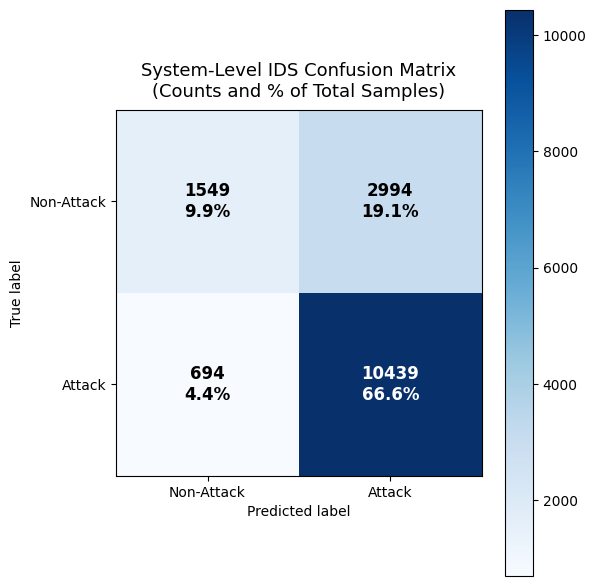

In [21]:
# ============================================================
# 6. System-Level Binary IDS Performance (TEST SET)
# ============================================================
# Purpose:
# - Evaluate the hierarchical IDS as a binary security system
# - Ignore internal routing; assess final Attack vs Non-Attack decision
# - Treat the hierarchy as a black-box IDS

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# System-Level IDS Performance (TEST SET)
# ------------------------------------------------------------

y_pred = results_df["Final_binary"].values

# Metrics
acc = accuracy_score(is_attack_test, y_pred)
prec = precision_score(is_attack_test, y_pred)
rec = recall_score(is_attack_test, y_pred)

print("System-Level IDS Metrics (TEST SET)")
print(f" Accuracy : {acc:.4f}")
print(f" Precision: {prec:.4f}")
print(f" Recall   : {rec:.4f}")

# Confusion matrix
cm = confusion_matrix(is_attack_test, y_pred)
total = cm.sum()

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Attack", "Attack"]
)
disp.plot(ax=ax, cmap="Blues", colorbar=True)

# Remove default annotations
for text in ax.texts:
    text.remove()

# Add custom annotations (COUNT on top, % below)
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct = 100 * count / total
        ax.text(
            j, i,
            f"{count}\n{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="white" if count > total * 0.25 else "black"
        )

ax.set_title(
    "System-Level IDS Confusion Matrix\n(Counts and % of Total Samples)",
    fontsize=13,
    pad=10
)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 7. Routing & Fallback Path Statistics (System-Level)
# ============================================================
# Purpose:
# - Quantify how samples traverse the hierarchical IDS
# - Show distribution across all routing outcomes
# - Verify SAFE fallback activation and confirmed attack rate
# - This analysis is system-level (not model-level)

# ------------------------------------------------------------
# Full routing-path distribution
# ------------------------------------------------------------
routing_stats = (
    results_df["Decision"]
    .value_counts(normalize=True)
    .rename("Fraction")
    .reset_index()
    .rename(columns={"index": "Routing Path"})
)

print("Routing Path Distribution (TEST SET)")
routing_stats

# ------------------------------------------------------------
# Derived routing metrics (interpretive summaries)
# ------------------------------------------------------------
attack_path_rate = (results_df["Decision"] != "M2_DIRECT").mean()
fallback_rate = (results_df["Decision"] == "FALLBACK_TO_M2").mean()
confirmed_attack_rate = (results_df["Decision"] == "ATTACK_CONFIRMED").mean()
direct_non_attack_rate = (results_df["Decision"] == "M2_DIRECT").mean()

print("\nDerived Routing Metrics")
print(f" Attack path rate (→ M3):        {attack_path_rate:.4f}")
print(f" Fallback activation rate:       {fallback_rate:.4f}")
print(f" Confirmed attack rate:          {confirmed_attack_rate:.4f}")
print(f" Direct non-attack routing rate: {direct_non_attack_rate:.4f}")

Routing Path Distribution (TEST SET)

Derived Routing Metrics
 Attack path rate (→ M3):        0.9571
 Fallback activation rate:       0.1002
 Confirmed attack rate:          0.8569
 Direct non-attack routing rate: 0.0429


In [23]:
# ============================================================
# 8. Per-Scenario Outcome Analysis (TEST SET)
# ============================================================
# Purpose:
# - Analyse final system decisions at the scenario level
# - Identify which true scenarios are correctly detected or misclassified
# - Provide error localisation for interpretability
#
# NOTE:
# - Uses true scenario markers (evaluation only)
# - Evaluates final hierarchical output, not individual models

# ------------------------------------------------------------
# Create correctness flag
# ------------------------------------------------------------
results_df["Correct"] = (
    (results_df["Final_binary"] == 1) &
    (~results_df["True_marker"].isin(NON_ATTACK_IDS))
) | (
    (results_df["Final_binary"] == 0) &
    (results_df["True_marker"].isin(NON_ATTACK_IDS))
)

# ------------------------------------------------------------
# Per-scenario summary
# ------------------------------------------------------------
scenario_summary = (
    results_df
    .groupby(["True_marker", "True_label_name"])
    .agg(
        Samples=("Correct", "size"),
        Accuracy=("Correct", "mean"),
        Attack_Pred_Rate=("Final_binary", "mean")
    )
    .reset_index()
    .sort_values("True_marker")
)

print("Per-Scenario Outcome Summary (TEST SET)")
display(scenario_summary)

# ------------------------------------------------------------
# Highlight weakest-performing scenarios
# ------------------------------------------------------------
print("\nLowest-Accuracy Scenarios:")
display(
    scenario_summary
    .sort_values("Accuracy")
    .head(8)
)

Per-Scenario Outcome Summary (TEST SET)


,True_marker,True_label_name,Samples,Accuracy,Attack_Pred_Rate
0,1,Fault L1 (10–19%),347,0.322767,0.677233
1,2,Fault L1 (20–79%),343,0.405248,0.594752
2,3,Fault L1 (80–90%),418,0.423445,0.576555
3,4,Fault L2 (10–19%),591,0.148900,0.851100
4,5,Fault L2 (20–79%),596,0.135906,0.864094
5,6,Fault L2 (80–90%),680,0.113235,0.886765
6,7,Data Injection: L1 Fault 10–19% with tripping,290,0.834483,0.834483
7,8,Data Injection: L1 Fault 20–79% with tripping,218,0.784404,0.784404
8,9,Data Injection: L1 Fault 80–90% with tripping,242,0.809917,0.809917
9,10,Data Injection: L2 Fault 10–19% with tripping,354,0.949153,0.949153



Lowest-Accuracy Scenarios:


,True_marker,True_label_name,Samples,Accuracy,Attack_Pred_Rate
5,6,Fault L2 (80–90%),680,0.113235,0.886765
4,5,Fault L2 (20–79%),596,0.135906,0.864094
13,14,Line Maintenance L2,350,0.145714,0.854286
3,4,Fault L2 (10–19%),591,0.148900,0.851100
0,1,Fault L1 (10–19%),347,0.322767,0.677233
1,2,Fault L1 (20–79%),343,0.405248,0.594752
2,3,Fault L1 (80–90%),418,0.423445,0.576555
12,13,Line Maintenance L1,332,0.515060,0.484940


In [24]:
# ============================================================
# 9. Error / Misrouting Analysis (End-to-End System)
# ============================================================
# Purpose:
# - Explain where end-to-end errors come from
# - Show how M1 conservative routing impacts non-attack scenarios
# - Quantify misrouting patterns by scenario and by decision path
#
# NOTE:
# - With the new M2 design, non-attacks output FAMILY labels only.
# - Therefore, scenario-level correctness is evaluated ONLY at the binary level
#   (Attack vs Non-Attack). Attack subtype correctness is handled separately.

# ------------------------------------------------------------
# 9.1 Binary correctness flag (system-level)
# ------------------------------------------------------------
true_is_attack = ~results_df["True_marker"].isin(NON_ATTACK_IDS)
pred_is_attack = (results_df["Final_binary"] == 1)

results_df["Binary_correct"] = (true_is_attack == pred_is_attack)

# ------------------------------------------------------------
# 9.2 Overall error rate and split by true class
# ------------------------------------------------------------
overall_error = 1 - results_df["Binary_correct"].mean()

non_attack_mask = results_df["True_marker"].isin(NON_ATTACK_IDS)
attack_mask = ~non_attack_mask

non_attack_error = 1 - results_df.loc[non_attack_mask, "Binary_correct"].mean()
attack_error = 1 - results_df.loc[attack_mask, "Binary_correct"].mean()

print("End-to-End Binary Error Summary (TEST SET)")
print(f" Overall error rate:       {overall_error:.4f}")
print(f" Non-attack error rate:    {non_attack_error:.4f}  (driven by conservative routing)")
print(f" Attack error rate:        {attack_error:.4f}")

# ------------------------------------------------------------
# 9.3 Where do non-attacks get misrouted?
# (i.e., true non-attack predicted as attack)
# ------------------------------------------------------------
non_attack_false_alarms = results_df[non_attack_mask & pred_is_attack].copy()

fa_by_scenario = (
    non_attack_false_alarms
    .groupby(["True_marker", "True_label_name"])
    .size()
    .reset_index(name="False_Alarm_Count")
    .sort_values("False_Alarm_Count", ascending=False)
)

print("\nTop non-attack scenarios misrouted as attacks (False Alarms):")
display(fa_by_scenario.head(10))

# Add rate relative to scenario size
scenario_sizes = results_df.groupby("True_marker").size().rename("Scenario_Samples")
fa_by_scenario = fa_by_scenario.merge(
    scenario_sizes.reset_index(),
    on="True_marker",
    how="left"
)
fa_by_scenario["False_Alarm_Rate"] = fa_by_scenario["False_Alarm_Count"] / fa_by_scenario["Scenario_Samples"]

print("\nFalse alarm rate by non-attack scenario:")
display(
    fa_by_scenario.sort_values("False_Alarm_Rate", ascending=False).head(10)
)

# ------------------------------------------------------------
# 9.4 Which decision path is responsible for errors?
# (This is the key "hierarchy behaviour" explanation)
# ------------------------------------------------------------
error_df = results_df[~results_df["Binary_correct"]].copy()

error_by_decision = (
    error_df["Decision"]
    .value_counts(normalize=True)
    .rename("Fraction_of_All_Errors")
    .reset_index()
    .rename(columns={"index": "Decision"})
)

print("\nError attribution by decision path (fraction of all errors):")
display(error_by_decision)

# ------------------------------------------------------------
# 9.5 Decision-path breakdown for non-attack false alarms
# ------------------------------------------------------------
fa_by_decision = (
    non_attack_false_alarms["Decision"]
    .value_counts(normalize=True)
    .rename("Fraction_of_NonAttack_FalseAlarms")
    .reset_index()
    .rename(columns={"index": "Decision"})
)

print("\nNon-attack false alarms: where they occur in the hierarchy")
display(fa_by_decision)

# ------------------------------------------------------------
# 9.6 Compact thesis table: worst non-attack scenarios + routing behaviour
# ------------------------------------------------------------
fa_thesis_table = (
    non_attack_false_alarms
    .groupby(["True_marker", "True_label_name", "Decision"])
    .size()
    .reset_index(name="Count")
    .merge(scenario_sizes.reset_index(), on="True_marker", how="left")
)

fa_thesis_table["Rate_within_scenario"] = fa_thesis_table["Count"] / fa_thesis_table["Scenario_Samples"]

print("\nThesis-ready table: non-attack misroutes by scenario and path")
display(
    fa_thesis_table
    .sort_values(["Rate_within_scenario", "Count"], ascending=False)
    .head(15)
)

End-to-End Binary Error Summary (TEST SET)
 Overall error rate:       0.2353
 Non-attack error rate:    0.6590  (driven by conservative routing)
 Attack error rate:        0.0623

Top non-attack scenarios misrouted as attacks (False Alarms):


,True_marker,True_label_name,False_Alarm_Count
5,6,Fault L2 (80–90%),603
4,5,Fault L2 (20–79%),515
3,4,Fault L2 (10–19%),503
7,14,Line Maintenance L2,299
2,3,Fault L1 (80–90%),241
0,1,Fault L1 (10–19%),235
8,41,Normal Operation (no disturbances),233
1,2,Fault L1 (20–79%),204
6,13,Line Maintenance L1,161



False alarm rate by non-attack scenario:


,True_marker,True_label_name,False_Alarm_Count,Scenario_Samples,False_Alarm_Rate
0,6,Fault L2 (80–90%),603,680,0.886765
1,5,Fault L2 (20–79%),515,596,0.864094
3,14,Line Maintenance L2,299,350,0.854286
2,4,Fault L2 (10–19%),503,591,0.851100
5,1,Fault L1 (10–19%),235,347,0.677233
7,2,Fault L1 (20–79%),204,343,0.594752
4,3,Fault L1 (80–90%),241,418,0.576555
8,13,Line Maintenance L1,161,332,0.484940
6,41,Normal Operation (no disturbances),233,886,0.262980



Error attribution by decision path (fraction of all errors):


,Decision,Fraction_of_All_Errors
0,ATTACK_CONFIRMED,0.811822
1,FALLBACK_TO_M2,0.100868
2,M2_DIRECT,0.087310



Non-attack false alarms: where they occur in the hierarchy


,Decision,Fraction_of_NonAttack_FalseAlarms
0,ATTACK_CONFIRMED,1.0



Thesis-ready table: non-attack misroutes by scenario and path


,True_marker,True_label_name,Decision,Count,Scenario_Samples,Rate_within_scenario
5,6,Fault L2 (80–90%),ATTACK_CONFIRMED,603,680,0.886765
4,5,Fault L2 (20–79%),ATTACK_CONFIRMED,515,596,0.864094
7,14,Line Maintenance L2,ATTACK_CONFIRMED,299,350,0.854286
3,4,Fault L2 (10–19%),ATTACK_CONFIRMED,503,591,0.851100
0,1,Fault L1 (10–19%),ATTACK_CONFIRMED,235,347,0.677233
1,2,Fault L1 (20–79%),ATTACK_CONFIRMED,204,343,0.594752
2,3,Fault L1 (80–90%),ATTACK_CONFIRMED,241,418,0.576555
6,13,Line Maintenance L1,ATTACK_CONFIRMED,161,332,0.484940
8,41,Normal Operation (no disturbances),ATTACK_CONFIRMED,233,886,0.262980


In [25]:
# ============================================================
# Section 10 - Attack Diagnostic Performance (TEST SET)
# ============================================================
# Purpose:
# - Evaluate fine-grained attack diagnosis (M4–M6)
# - Only for samples that reached ATTACK_CONFIRMED
# - Excludes routing and fallback behaviour by design

from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# Filter: true attacks that reached a specialist leaf
# ------------------------------------------------------------
attack_df = results_df[
    (results_df["True_marker"].isin(DI_IDS + RT_IDS + RSC_IDS)) &
    (results_df["Decision"] == "ATTACK_CONFIRMED")
].copy()

print("Attack-only samples used:", len(attack_df))
print("Unique attack scenarios:", attack_df["True_marker"].nunique())

# ------------------------------------------------------------
# Overall attack diagnostic accuracy
# ------------------------------------------------------------
attack_accuracy = accuracy_score(
    attack_df["True_marker"],
    attack_df["Final_class"]
)

print("\nOverall attack diagnostic accuracy:")
print(f" Accuracy: {attack_accuracy:.4f}")

# ------------------------------------------------------------
# Family-level diagnostic accuracy
# ------------------------------------------------------------
def attack_family(marker):
    if marker in DI_IDS:
        return "Data Injection"
    elif marker in RT_IDS:
        return "Remote Tripping"
    elif marker in RSC_IDS:
        return "Relay Setting Change"
    else:
        return "Unknown"

attack_df["Attack_Family"] = attack_df["True_marker"].apply(attack_family)

# ------------------------------------------------------------
# Family-level diagnostic accuracy (future-proof)
# ------------------------------------------------------------
family_accuracy = (
    attack_df
    .groupby("Attack_Family")[["True_marker", "Final_class"]]
    .apply(lambda g: accuracy_score(g["True_marker"], g["Final_class"]))
    .rename("Accuracy")
    .reset_index()
)

print("\nFamily-level diagnostic accuracy:")
display(family_accuracy)

# ------------------------------------------------------------
# Coverage diagnostic (what fraction of attacks were diagnosed)
# ------------------------------------------------------------
total_true_attacks = results_df["True_marker"].isin(DI_IDS + RT_IDS + RSC_IDS).sum()
diagnosed_attacks = len(attack_df)

print("\nDiagnostic coverage:")
print(f" Fraction of true attacks reaching leaf classifiers: "
      f"{diagnosed_attacks / total_true_attacks:.4f}")

Attack-only samples used: 10439
Unique attack scenarios: 28

Overall attack diagnostic accuracy:
 Accuracy: 0.9602

Family-level diagnostic accuracy:


,Attack_Family,Accuracy
0,Data Injection,0.936594
1,Relay Setting Change,0.969391
2,Remote Tripping,0.943058



Diagnostic coverage:
 Fraction of true attacks reaching leaf classifiers: 0.9377


In [26]:

# ============================================================
# Non-Attack Diagnostic (TEST SET)
# Scenario-group aligned, SLG/L2-safe
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# Scenario Groups (from your definition)
# ------------------------------------------------------------

SLG_IDS     = [1, 2, 3, 4, 5, 6]
MAINT_IDS   = [13, 14]
NORMAL_IDS  = [41]

NON_ATTACK_IDS = SLG_IDS + MAINT_IDS + NORMAL_IDS

# ------------------------------------------------------------
# Non-Attack Scenario → Family mapping
# ------------------------------------------------------------

NON_ATTACK_FAMILY_LOOKUP = {}

for k in SLG_IDS:
    NON_ATTACK_FAMILY_LOOKUP[k] = "SLG Faults"

for k in MAINT_IDS:
    NON_ATTACK_FAMILY_LOOKUP[k] = "Line Maintenance"

for k in NORMAL_IDS:
    NON_ATTACK_FAMILY_LOOKUP[k] = "Normal Operation"

# ------------------------------------------------------------
# Filter ALL non-attack samples
# ------------------------------------------------------------

non_attack_df = results_df[
    results_df["True_marker"].isin(NON_ATTACK_IDS)
].copy()

# Explicit family column (critical)
non_attack_df["Non_Attack_Family"] = non_attack_df["True_marker"].map(
    NON_ATTACK_FAMILY_LOOKUP
)

# ------------------------------------------------------------
# Aggregate totals and false alarms
# ------------------------------------------------------------

total_counts = (
    non_attack_df
    .groupby("Non_Attack_Family")
    .size()
    .rename("Total_Samples")
)

false_alarm_counts = (
    non_attack_df[non_attack_df["Final_binary"] == 1]
    .groupby("Non_Attack_Family")
    .size()
    .rename("False_Alarms")
)

# ------------------------------------------------------------
# Combine + compute false-alarm rate
# ------------------------------------------------------------

diagnostic_df = (
    pd.concat([total_counts, false_alarm_counts], axis=1)
    .fillna(0)
)

diagnostic_df["False_Alarm_Rate (%)"] = (
    diagnostic_df["False_Alarms"] / diagnostic_df["Total_Samples"]
) * 100

diagnostic_df = diagnostic_df.reset_index()

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("Non-Attack Diagnostic Summary (TEST SET)")
display(diagnostic_df)

Non-Attack Diagnostic Summary (TEST SET)


,Non_Attack_Family,Total_Samples,False_Alarms,False_Alarm_Rate (%)
0,Line Maintenance,682,460,67.448680
1,Normal Operation,886,233,26.297968
2,SLG Faults,2975,2301,77.344538


Table 11.1 — Non-Attack False Alarms and Misrouting Summary (TEST SET)


,Total_Samples,False_Alarms,False Alarm Rate (%),Data Injection Misroute (%),Relay Setting Change Misroute (%),Remote Tripping Misroute (%)
Non_Attack_Family,,,,,,
SLG Faults,2975,2263,76.1,19.0,71.1,9.9
Line Maintenance,682,438,64.2,15.3,70.3,14.4
Normal Operation,886,239,27.0,5.4,85.4,9.2


<Figure size 1000x500 with 0 Axes>

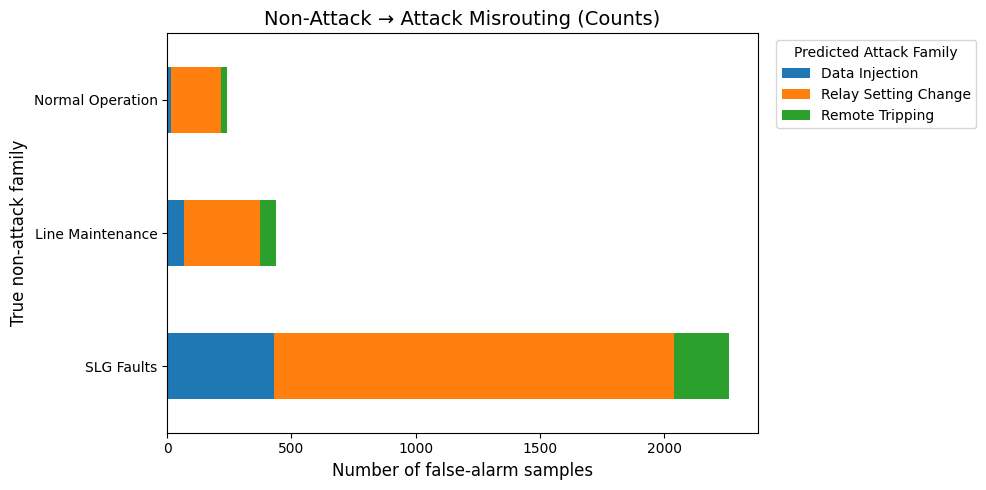

In [200]:

# ============================================================
# Section 11.1 — Non-Attack → Attack Misrouting (FINAL)
# Table + Simple Stacked Bar (Counts Only)
# ============================================================

# ============================================================
# Section 11.1 — Non-Attack False Alarms & Misrouting (ONE TABLE)
# Robust version: NO groupby.apply
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Scenario Groups
# ------------------------------------------------------------
SLG_IDS     = [1, 2, 3, 4, 5, 6]
MAINT_IDS   = [13, 14]
NORMAL_IDS  = [41]

NON_ATTACK_IDS = SLG_IDS + MAINT_IDS + NORMAL_IDS

DI_IDS  = [7, 8, 9, 10, 11, 12]
RT_IDS  = [15, 16, 17, 18, 19, 20]
RSC_IDS = [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 35, 36, 37, 38, 39, 40]

# ------------------------------------------------------------
# Lookups
# ------------------------------------------------------------
NON_ATTACK_FAMILY_LOOKUP = {}
for k in SLG_IDS:    NON_ATTACK_FAMILY_LOOKUP[k] = "SLG Faults"
for k in MAINT_IDS:  NON_ATTACK_FAMILY_LOOKUP[k] = "Line Maintenance"
for k in NORMAL_IDS: NON_ATTACK_FAMILY_LOOKUP[k] = "Normal Operation"

ATTACK_FAMILY_LOOKUP = {}
for k in DI_IDS:  ATTACK_FAMILY_LOOKUP[k]  = "Data Injection"
for k in RT_IDS:  ATTACK_FAMILY_LOOKUP[k]  = "Remote Tripping"
for k in RSC_IDS: ATTACK_FAMILY_LOOKUP[k]  = "Relay Setting Change"

# ------------------------------------------------------------
# Filter non-attack samples + map families
# ------------------------------------------------------------
df = results_df.loc[
    results_df["True_marker"].isin(NON_ATTACK_IDS),
    ["True_marker", "Final_binary", "Final_class"]
].copy()

df["Non_Attack_Family"] = df["True_marker"].map(NON_ATTACK_FAMILY_LOOKUP)

# Predicted attack family ONLY for false alarms
df["Pred_Attack_Family"] = np.where(
    df["Final_binary"] == 1,
    df["Final_class"].map(ATTACK_FAMILY_LOOKUP),
    np.nan
)

# ------------------------------------------------------------
# Base aggregation (counts)
# ------------------------------------------------------------
base = (
    df.groupby("Non_Attack_Family")
      .agg(
          Total_Samples=("Final_binary", "size"),
          False_Alarms=("Final_binary", "sum")
      )
)

base["False Alarm Rate (%)"] = (
    base["False_Alarms"] / base["Total_Samples"] * 100
)

# ------------------------------------------------------------
# Misrouting counts (false alarms only)
# ------------------------------------------------------------
misroute_counts = (
    df[df["Final_binary"] == 1]
    .groupby(["Non_Attack_Family", "Pred_Attack_Family"])
    .size()
    .unstack(fill_value=0)
)

# Ensure all attack families exist as columns
for col in ["Data Injection", "Relay Setting Change", "Remote Tripping"]:
    if col not in misroute_counts.columns:
        misroute_counts[col] = 0

# ------------------------------------------------------------
# Convert misrouting to percentages
# ------------------------------------------------------------
misroute_pct = (
    misroute_counts
    .div(misroute_counts.sum(axis=1).replace(0, 1), axis=0)
    * 100
)

# ------------------------------------------------------------
# Build FINAL table (one object, no join confusion)
# ------------------------------------------------------------
section_11_1_table = pd.concat(
    [
        base,
        misroute_pct[[
            "Data Injection",
            "Relay Setting Change",
            "Remote Tripping"
        ]].add_suffix(" Misroute (%)")
    ],
    axis=1
).round(1)

# Force preferred order
order = ["SLG Faults", "Line Maintenance", "Normal Operation"]
section_11_1_table = section_11_1_table.reindex(order)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
print("Table 11.1 — Non-Attack False Alarms and Misrouting Summary (TEST SET)")
display(section_11_1_table)

# ------------------------------------------------------------
# Extract misrouting counts from the same pipeline
# ------------------------------------------------------------

bar_data = misroute_counts.reindex(
    ["SLG Faults", "Line Maintenance", "Normal Operation"],
    fill_value=0
)

# ------------------------------------------------------------
# Plot: stacked horizontal bar (COUNTS)
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))

misrouting_counts.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 5)
)

plt.xlabel("Number of false-alarm samples", fontsize=12)
plt.ylabel("True non-attack family", fontsize=12)
plt.title(
    "Non-Attack → Attack Misrouting (Counts)",
    fontsize=14
)

plt.legend(
    title="Predicted Attack Family",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

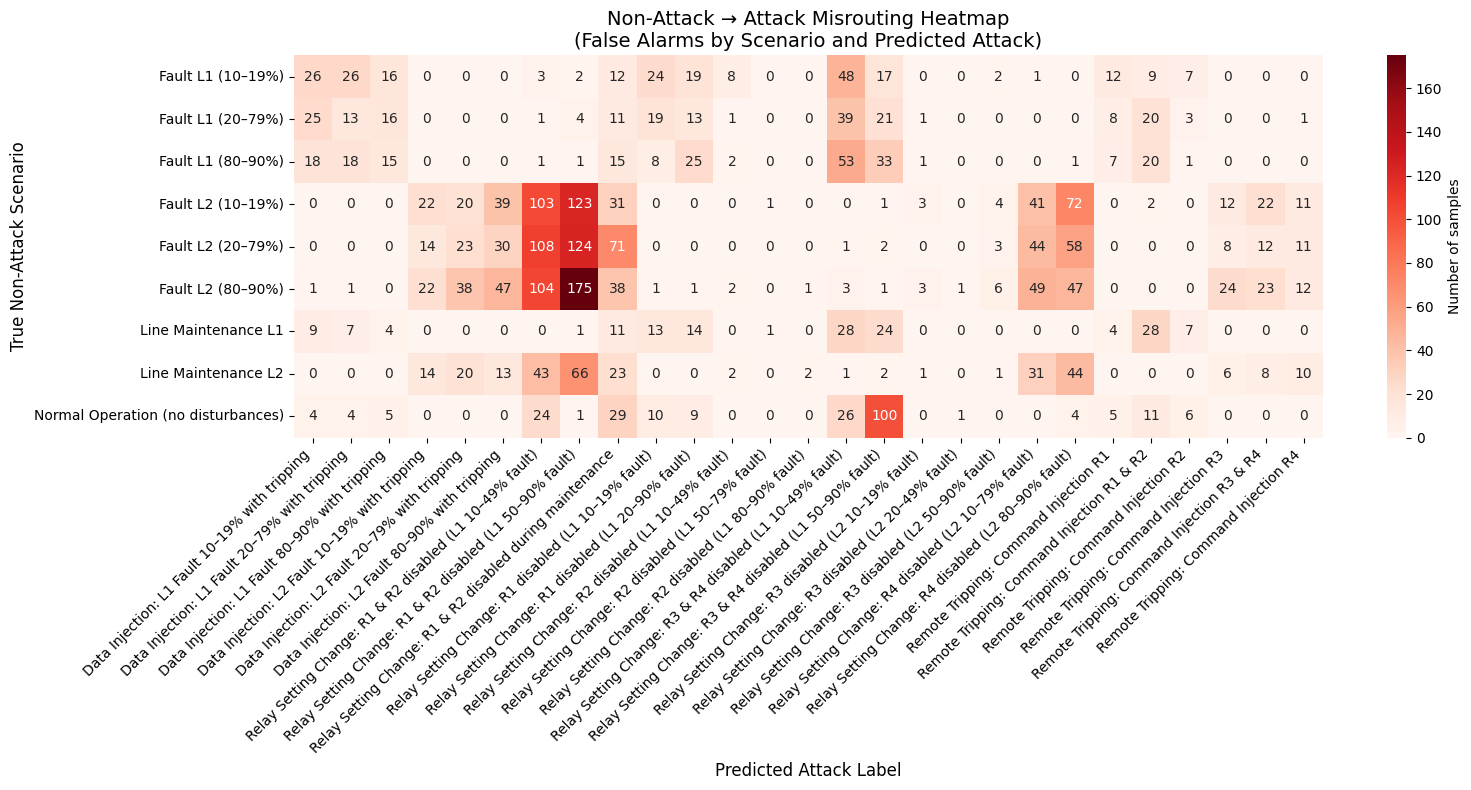

In [148]:
# ============================================================
# Section 11.2 — Non-Attack → Attack Misrouting Heatmap
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# Pivot table for heatmap
# ----------------------------
heatmap_data = (
    false_alarm_df
    .groupby(["True_label_name", "Final_label"])
    .size()
    .unstack(fill_value=0)
)

# ----------------------------
# Plot heatmap (large, readable)
# ----------------------------
plt.figure(figsize=(16, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar_kws={"label": "Number of samples"}
)

plt.xlabel("Predicted Attack Label", fontsize=12)
plt.ylabel("True Non-Attack Scenario", fontsize=12)
plt.title(
    "Non-Attack → Attack Misrouting Heatmap\n"
    "(False Alarms by Scenario and Predicted Attack)",
    fontsize=14
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [18]:
DI_IDS  = list(range(7,13))
RT_IDS  = list(range(15,21))
RSC_IDS = list(range(21,31)) + list(range(35,41))

def map_family(marker):
    if marker in DI_IDS:
        return "DI"
    elif marker in RT_IDS:
        return "RT"
    elif marker in RSC_IDS:
        return "RSC"
    else:
        return "NON_ATTACK"

y_family_true = y_marker.loc[X_test.index].apply(map_family).values

family_recalls = {}
for fam in ["DI","RT","RSC"]:
    mask = (y_family_true == fam)
    family_recalls[fam] = (y_pred[mask] == 1).mean() if mask.sum() else np.nan

pd.DataFrame.from_dict(family_recalls, orient="index", columns=["Recall"])


,Recall
DI,0.877430
RT,0.874785
RSC,0.955438


In [10]:
scenario_confusion = (
    pd.DataFrame({
        "marker": y_marker.loc[X_test.index].values,
        "attack_true": is_attack_test.values,
        "attack_pred": y_pred
    })
    .groupby("marker")
    .agg(
        total=("attack_true","size"),
        attack_rate_true=("attack_true","mean"),
        attack_rate_pred=("attack_pred","mean")
    )
    .sort_values("total", ascending=False)
)

scenario_confusion.head(10)


,total,attack_rate_true,attack_rate_pred
marker,,,
36,996,1.0,0.983936
41,886,0.0,0.269752
35,863,1.0,0.990730
6,680,0.0,0.882353
5,596,0.0,0.854027
4,591,0.0,0.857868
23,522,1.0,1.000000
37,517,1.0,0.802708
25,508,1.0,1.000000


### Deployment Pseudocode

INPUT: sample x

1. Compute p_attack = M1(x)

2. IF p_attack < TAU_GATE:
       y = M2(x)
       RETURN NonAttack(y)

3. ELSE:
       (c3, conf3) = M3(x)

       IF conf3 < CONF_FALLBACK AND p_attack < TAU_GATE + SAFE_MARGIN:
           y = M2(x)
           RETURN NonAttack(y)

       ELSE:
           IF c3 == DI:
               y = M4(x)
           ELSE IF c3 == RT:
               y = M5(x)
           ELSE:
               y = M6(x)

           RETURN Attack(y)


### Final Takeaway

The end-to-end evaluation confirms that the hierarchical IDS executes deterministically
with all models (M1–M6) engaged according to the designed routing logic.
The SAFE fallback mechanism activates selectively, reducing misrouted non-attacks
while preserving safety-critical attack detections.
All results reflect final system behaviour on unseen test data.
